In [ ]:
# ============================================================
# 3.3 FUZZY ADJUVANT MATCHING (CONSISTENT WITH UTILS)
# ============================================================

import os
import re
import json
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
from rapidfuzz import fuzz, process


from utils import canonical_normalize, safe_to_list

# -----------------------------
# CONFIG
# -----------------------------
LEXICON_CSV = "Dataset/VIOLIN_12-10-2025/interim/adjuvant_ner_lexicon_clean.csv"
ABSTRACTS_JSONL = "Dataset/VIOLIN_12-10-2025/interim/pubmed_abstracts.jsonl"
OUT_DIR = "Dataset/VIOLIN_12-10-2025/interim/fuzzy_matches"

FUZZY_THRESHOLD = 96
NGRAM_MIN = 2
NGRAM_MAX = 6
TOPK_CANDIDATES_PER_SPAN = 8

MIN_SPAN_TOKENS = 2
MAX_DICT_TO_SPAN_RATIO = 1.5
MIN_TOKEN_COVERAGE = 0.5

os.makedirs(OUT_DIR, exist_ok=True)





NUM_RE = re.compile(r"\d+")
GREEK_MAP = {
    "alpha": "α", "beta": "β", "gamma": "γ", "delta": "δ",
    "epsilon": "ε", "kappa": "κ", "lambda": "λ", "mu": "μ", "omega": "ω",
}
GREEK_RE = re.compile(r"\b(alpha|beta|gamma|delta|epsilon|kappa|lambda|mu|omega)\b", re.I)
GREEK_SYMBOL_RE = re.compile(r"[αβγδεκλμω]")

def numbers_in(text):
    return NUM_RE.findall(text) if isinstance(text, str) else []

def greek_tokens(text):
    if not isinstance(text, str):
        return []
    t = text.lower()
    t = GREEK_RE.sub(lambda m: GREEK_MAP[m.group(1)], t)
    return GREEK_SYMBOL_RE.findall(t)

def enforce_number_greek_consistency(span, dict_term):
    span_nums = numbers_in(span)
    dict_nums = numbers_in(dict_term)
    if span_nums or dict_nums:
        if span_nums != dict_nums:
            return False

    span_greek = greek_tokens(span)
    dict_greek = greek_tokens(dict_term)
    if span_greek or dict_greek:
        if span_greek != dict_greek:
            return False

    return True

def enforce_complete_incomplete(span, dict_term):
    s = span.lower()
    d = dict_term.lower()
    span_has = "complete" in s
    span_has_in = "incomplete" in s
    dict_has = "complete" in d
    dict_has_in = "incomplete" in d
    # mismatch if one says complete and the other says incomplete
    if (span_has and dict_has_in) or (span_has_in and dict_has):
        return False
    return True

# -----------------------------
# NORMALIZATION (consistent)
# -----------------------------
def normalize(s: str):
    if not isinstance(s, str):
        return None
    return canonical_normalize(s)

# -----------------------------
# GENERIC TERMS TO DROP
# -----------------------------
GENERIC_EXACT = {
    "adjuvant",
    "vaccine",
    "vaccine adjuvant",
    "adjuvant component",
    "component",
    "vaxjo adjuvant",
    "vaccine component",
}




GENERIC_EXACT_NORM = {normalize(x) for x in GENERIC_EXACT if normalize(x)}

# -----------------------------
# STOPWORDS / HELPERS
# -----------------------------
LEADING_STOP = {
    "a","an","the","to","of","and","or","either","as",
    "in","on","for","with","by","from","into","via"
}
TRAILING_STOP = LEADING_STOP | {
    "have","has","had","were","was","is","are","be","been","being"
}
NUM_TOKEN_RE = re.compile(r"^\d+$")

def trim_span(tokens):
    i, j = 0, len(tokens)
    while i < j and (tokens[i] in LEADING_STOP or NUM_TOKEN_RE.match(tokens[i])):
        i += 1
    while j > i and (tokens[j-1] in TRAILING_STOP or NUM_TOKEN_RE.match(tokens[j-1])):
        j -= 1
    return tokens[i:j], i, j - i

# -----------------------------
# LOAD + CLEAN LEXICON
# -----------------------------
lex = pd.read_csv(LEXICON_CSV, dtype=str).fillna("")

lex["synonyms"] = lex["synonyms"].apply(safe_to_list)
lex["expanded_forms"] = lex["expanded_forms"].apply(safe_to_list)

term_to_vos = defaultdict(set)

for _, row in lex.iterrows():
    vo = row["adjuvant_vo_id"]

    fields = (
        [row.get("preferred_name", "")] +
        row["synonyms"] +
        row["expanded_forms"]
    )

    for f in fields:
        norm = normalize(f)
        if not norm:
            continue

        # remove generic exact terms
        if norm in GENERIC_EXACT_NORM:
            continue

        toks = norm.split()

        # remove long/sentence-like entries
        if len(toks) > 7:
            continue
        if toks[0] in LEADING_STOP:
            continue
        if "either" in toks and "or" in toks:
            continue

        term_to_vos[norm].add(vo)

dictionary_terms = sorted(term_to_vos)
print(f"Loaded {len(dictionary_terms)} cleaned dictionary terms")

# -----------------------------
# LOAD ABSTRACTS
# -----------------------------
abstracts = []
with open(ABSTRACTS_JSONL, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            abstracts.append(json.loads(line))

# -----------------------------
# N-GRAM GENERATOR
# -----------------------------
def generate_ngrams(tokens):
    L = len(tokens)
    for n in range(NGRAM_MIN, NGRAM_MAX + 1):
        for i in range(L - n + 1):
            yield tokens[i:i+n], i, n

# -----------------------------
# FUZZY MATCHING
# -----------------------------
records = []

for rec in tqdm(abstracts, desc="Fuzzy matching"):
    pmid = rec.get("pmid")
    abstract = rec.get("abstract", "")
    if not pmid or not abstract:
        continue

    tokens = normalize(abstract).split() if normalize(abstract) else []
    if not tokens:
        continue

    seen = set()

    for raw_tokens, start, n in generate_ngrams(tokens):
        trimmed, delta, new_n = trim_span(raw_tokens)
        if new_n < MIN_SPAN_TOKENS:
            continue

        span = " ".join(trimmed)
        if not span or span in seen:
            continue
        seen.add(span)

        candidates = process.extract(
            span,
            dictionary_terms,
            scorer=fuzz.partial_ratio,
            limit=TOPK_CANDIDATES_PER_SPAN
        )

        for dict_term, score, _ in candidates:
            if not enforce_number_greek_consistency(span, dict_term):
                continue
            if not enforce_complete_incomplete(span, dict_term):
                continue

            if score < FUZZY_THRESHOLD:
                continue

            span_toks = span.split()
            dict_toks = dict_term.split()

            if len(dict_toks) > len(span_toks) * MAX_DICT_TO_SPAN_RATIO:
                continue

            coverage = len(set(span_toks) & set(dict_toks)) / len(set(dict_toks))
            if coverage < MIN_TOKEN_COVERAGE:
                continue

            for vo in term_to_vos[dict_term]:
                records.append({
                    "pmid": str(pmid),
                    "adjuvant_vo_id": vo,
                    "matched_text": span,
                    "dictionary_term": dict_term,
                    "score": int(score),
                    "match_type": "fuzzy",
                    "span_start_token": start + delta,
                    "span_len_tokens": new_n,
                })

# -----------------------------
# SAVE OUTPUTS
# -----------------------------
df = pd.DataFrame(records)

csv_out = os.path.join(OUT_DIR, "matched_fuzzy_adjuvants.csv")
jsonl_out = os.path.join(OUT_DIR, "matched_fuzzy_abstracts.jsonl")

df.to_csv(csv_out, index=False, encoding="utf-8-sig")

with open(jsonl_out, "w", encoding="utf-8") as out:
    for pmid, g in df.groupby("pmid"):
        out.write(json.dumps({
            "pmid": pmid,
            "matches": g.to_dict(orient="records"),
            "num_matches": int(len(g)),
            "num_unique_adjuvants": int(g["adjuvant_vo_id"].nunique())
        }, ensure_ascii=False) + "\n")

# -----------------------------
# STATS
# -----------------------------
print("\n✅ FUZZY MATCHING COMPLETE")
print(f"• Total mentions: {len(df)}")
print(f"• Unique PMIDs: {df['pmid'].nunique() if not df.empty else 0}")
print(f"• Unique VO IDs: {df['adjuvant_vo_id'].nunique() if not df.empty else 0}")
print(f"• CSV: {csv_out}")
print(f"• JSONL: {jsonl_out}")


Loaded 286 cleaned dictionary terms


Fuzzy matching: 100%|██████████| 1341/1341 [05:21<00:00,  4.18it/s]



✅ FUZZY MATCHING COMPLETE
• Total mentions: 6832
• Unique PMIDs: 317
• Unique VO IDs: 72
• CSV: Dataset/VIOLIN_12-10-2025/interim/fuzzy_matches\matched_fuzzy_adjuvants.csv
• JSONL: Dataset/VIOLIN_12-10-2025/interim/fuzzy_matches\matched_fuzzy_abstracts.jsonl


,threshold,unique_vo,unique_pmids,mentions
0,96,72,317,6832
1,98,72,315,6563
2,100,72,315,6550


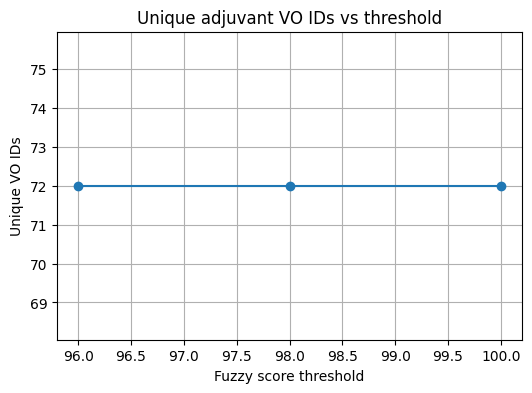

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Dataset/VIOLIN_12-10-2025/interim/fuzzy_matches/matched_fuzzy_adjuvants.csv", encoding="utf-8-sig")

# thresholds to test
thresholds = list(range(96, 101, 2))

rows = []
for t in thresholds:
    sub = df[df["score"] >= t]
    rows.append({
        "threshold": t,
        "unique_vo": sub["adjuvant_vo_id"].nunique(),
        "unique_pmids": sub["pmid"].nunique(),
        "mentions": len(sub)
    })

stats = pd.DataFrame(rows)
display(stats)

# plot unique VO IDs vs threshold
plt.figure(figsize=(6,4))
plt.plot(stats["threshold"], stats["unique_vo"], marker="o")
plt.xlabel("Fuzzy score threshold")
plt.ylabel("Unique VO IDs")
plt.title("Unique adjuvant VO IDs vs threshold")
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd
import json

# --- exact ---
exact_csv = "Dataset/VIOLIN_12-10-2025/interim/exact_matches/matched_exact_adjuvants.csv"
exact = pd.read_csv(exact_csv, encoding="utf-8-sig")
exact_vos = sorted(exact["adjuvant_vo_id"].dropna().unique())

# --- fuzzy (choose threshold) ---
fuzzy_csv = "Dataset/VIOLIN_12-10-2025/interim/fuzzy_matches/matched_fuzzy_adjuvants.csv"
fuzzy = pd.read_csv(fuzzy_csv, encoding="utf-8-sig")
THRESH = 90
fuzzy_vos = sorted(fuzzy[fuzzy["score"] >= THRESH]["adjuvant_vo_id"].dropna().unique())

# --- compare ---
only_in_fuzzy = sorted(set(fuzzy_vos) - set(exact_vos))
only_in_exact = sorted(set(exact_vos) - set(fuzzy_vos))

print("Exact unique VO IDs:", len(exact_vos))
print("Fuzzy unique VO IDs (>=THRESH):", len(fuzzy_vos))
print("Only in fuzzy:", len(only_in_fuzzy))
print("Only in exact:", len(only_in_exact))

# optional: save lists
pd.Series(exact_vos).to_csv("Dataset/VIOLIN_12-10-2025/interim/exact_unique_vo_ids.csv", index=False, header=["adjuvant_vo_id"], encoding="utf-8-sig")
pd.Series(fuzzy_vos).to_csv(f"Dataset/VIOLIN_12-10-2025/interim/fuzzy_unique_vo_ids_t{THRESH}.csv", index=False, header=["adjuvant_vo_id"], encoding="utf-8-sig")
pd.Series(only_in_fuzzy).to_csv(f"Dataset/VIOLIN_12-10-2025/interim/fuzzy_only_vo_ids_t{THRESH}.csv", index=False, header=["adjuvant_vo_id"], encoding="utf-8-sig")
pd.Series(only_in_exact).to_csv(f"Dataset/VIOLIN_12-10-2025/interim/exact_only_vo_ids_t{THRESH}.csv", index=False, header=["adjuvant_vo_id"], encoding="utf-8-sig")

Exact unique VO IDs: 55
Fuzzy unique VO IDs (>=THRESH): 72
Only in fuzzy: 17
Only in exact: 0


In [ ]:
import pandas as pd

lex = pd.read_csv("Dataset/VIOLIN_12-10-2025/interim/adjuvant_ner_lexicon_clean.csv")
lex = lex[["adjuvant_vo_id","preferred_name"]].drop_duplicates()

fuzzy_csv = "Dataset/VIOLIN_12-10-2025/interim/fuzzy_matches/matched_fuzzy_adjuvants.csv"
fuzzy = pd.read_csv(fuzzy_csv, encoding="utf-8-sig")

THRESH = 90

# load exact and fuzzy sets
exact = pd.read_csv("Dataset/VIOLIN_12-10-2025/interim/exact_matches/matched_exact_adjuvants.csv", encoding="utf-8-sig")
exact_vos = set(exact["adjuvant_vo_id"].dropna())
fuzzy_vos = set(fuzzy[fuzzy["score"] >= THRESH]["adjuvant_vo_id"].dropna())

only_in_fuzzy = sorted(fuzzy_vos - exact_vos)

# frequency for fuzzy-only
freq = (fuzzy[fuzzy["score"] >= THRESH]
        .query("adjuvant_vo_id in @only_in_fuzzy")
        .groupby("adjuvant_vo_id")
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False))

out = freq.merge(lex, on="adjuvant_vo_id", how="left")
display(out)


,adjuvant_vo_id,count,preferred_name
0,VO_0005271,24,2B182C
1,VO_0000190,12,Squalene-based Adjuvants
2,VO_0000884,11,Aluminum vaccine adjuvant
3,VO_0001307,9,Non-Ionic Surfactant Vesicles
4,VO_0001302,9,MTP-PE Liposomes
5,VO_0001345,6,MPL-SE vaccine adjuvant
6,VO_0001341,6,DL-PGL (Polyester poly (DL-lactide-co-glycolid...
7,VO_0001289,3,Calcium Phosphate Gel
8,VO_0001290,3,CTA1-DD gene fusion protein
9,VO_0001335,2,Albumin-heparin microparticles vaccine adjuvant
